# Mooooodellllll

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
import holidays
from rapidfuzz import process, fuzz
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


import pickle
from pathlib import Path
import re

import shap

# Linear
from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)

# Tree / Ensemble
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from datetime import datetime

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [39]:
def read_sheets(filename):
    """Read the input data"""
    sheets = pd.read_excel(filename, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)
    return df.shape, df

df_time_shape, df_time = read_sheets("time_card_daily_latest.xlsx")
print(f"Time shape: {df_time_shape}")

Time shape: (131036, 16)


## ABT Build

In [40]:
def clean_name(name):
    if pd.isna(name):
        return name
    
    if "," in name:
        parts = [p.strip() for p in name.split(",")]
    else:
        parts = [p.strip() for p in name.split(" ")]

    first_name = parts[-1]
    last_name = parts[0]

    if "," in name:
        return f"{first_name} {last_name}".lower()
    else:
        return f"{last_name} {first_name}".lower()

In [41]:
offboarded = pd.read_excel("Resources.xlsx", sheet_name="Offboarded Resources")
offboarded["Offboarded"] = True
active = pd.read_excel("Resources.xlsx", sheet_name="Resource List 20250206")
active["Offboarded"] = False
sheets = [
    active,
    offboarded
          
]
df_staff = pd.concat(sheets, ignore_index=True)
df_staff.drop([
    "Cross checked",
    "Location",
    "In DL",
    "Pod",
    "Email",
    "Gender",
    "Onboarding Done",
    "Source",
    "Seniority",
    "Pod Lead",
    "Nationality",
    "Active"
], axis=1, inplace=True)

In [42]:
df_staff['Name'] = df_staff['Name'].apply(clean_name)
df_staff = df_staff[df_staff['Technology'] != 'ServiceNow']
df_staff = df_staff.sort_values(by="Offboarded", ascending=False)

In [43]:
df_time["User"] = df_time["User"].apply(clean_name)
len(df_time) # before removing GEN

131036

In [44]:
task_types = ["INC", "CHG", "SCT"]

df_time["is_sick_or_holiday"] = df_time["Category"].isin(["Sick/Holiday"]).astype(int)

df_time = df_time[
    df_time["Task"].str.startswith(tuple(task_types), na=False)
    | df_time["Category"].isin(["Sick/Holiday"])
]

In [45]:
df_time["Category"].value_counts()

Category
Task work       58352
Sick/Holiday     5127
Name: count, dtype: int64

In [46]:
df_time.loc[df_time["is_sick_or_holiday"] == 1, "Time worked"] = 0

In [47]:
len(df_time)

63479

In [48]:
len(df_staff["Name"].unique())

203

In [49]:
len(df_time["User"].unique())

155

In [50]:
staff_names = df_staff["Name"].tolist()

df_time["closest_match"] = df_time["User"].apply(
    lambda x: process.extractOne(
        x,
        staff_names,
        scorer=fuzz.token_sort_ratio
    )[0] if pd.notna(x) else None
)

In [51]:
len(df_time)

63479

In [52]:
override_map = {
    "klevis dedaj": "None",
    "kim matos": "kim shimabukuro matos",
    "sadri salihu": "None",
    "valentina gonzalez": "None",
    "sarudzai midzi": "None",
    "arena hysi": "None",
    "danka biocanin": "None",
    "chady mattar": "None",
    "alisha kalan": "None",
    "ailsa thompson": "None",
    "michael ogunniyi": "None",
    "snehalata vidhi": "None",
    "sri sai": "None",
    "rina bardoniqi": "None",
    "purvesh kulkarni": "None",
    "ashok bishnoi": "None",
    "richard hims": "None",
    "syedkhurram mehdi": "None",
    "fouziasunder bhatti": "None",
    "clementina buttigieg": "None",
    "robert gauci": "None",
    "purvesh kulkarni": "None",
    "widad elasly": "None"
}

In [53]:
df_time["final_name"] = df_time["closest_match"]

mask = df_time["User"].isin(override_map.keys())
df_time.loc[mask, "final_name"] = df_time.loc[mask, "User"].map(override_map)

In [54]:
mismatches = df_time[df_time["User"] != df_time["final_name"]][["User", "final_name"]]
#mismatches.value_counts()

In [55]:
len(df_time)

63479

In [56]:
df_time["_row_id"] = range(len(df_time))

In [57]:
df_merged = df_time.merge(
    df_staff[["Name", "Allocation to MS", "Date of Joining", "Date of Leaving"]],
    left_on="final_name", right_on="Name", how="left")
df_merged.drop(["closest_match", "User", "Additional comments", "Rate type", "Business Services"], axis=1, inplace=True)
len(df_merged)

63479

In [58]:
dup_expansion = df_merged[df_merged.duplicated("_row_id", keep=False)]

In [59]:
expansion_counts = df_merged["_row_id"].value_counts()
expansion_counts = expansion_counts[expansion_counts > 1]

In [60]:
problem_rows = df_merged[df_merged["_row_id"].isin(expansion_counts.index)]
problem_rows.sort_values("_row_id")

,Date,Task,Short description,Company,Business service,Project ID,Technology,User ID,Category,Time worked,Grade,Specialisation,is_sick_or_holiday,final_name,_row_id,Name,Allocation to MS,Date of Joining,Date of Leaving


In [61]:
df_merged.drop(["Name", "Company", "Short description",
                "Business service", "Project ID", "Grade",
                "_row_id"
], axis=1, inplace=True)
df_merged.head(5)

,Date,Task,Technology,User ID,Category,Time worked,Specialisation,is_sick_or_holiday,final_name,Allocation to MS,Date of Joining,Date of Leaving
0,2024-05-01,INC0027304,Dynamics 365 FO,VaibhavVinayak.Sane,Task work,1.0,NaN,0,vaibhav vinayak sane,1.0,NaN,NaT
1,2024-05-01,INC0027284,Dynamics 365 FO,chiamakajoy.ichoku,Task work,0.5,NaN,0,chiamaka joy ichoku,1.0,NaN,NaT
2,2024-05-01,INC0027321,Dynamics 365 FO,VaibhavVinayak.Sane,Task work,1.0,NaN,0,vaibhav vinayak sane,1.0,NaN,NaT
3,2024-05-01,INC0027249,Dynamics 365 BC,joseph.pellicano,Task work,2.0,NaN,0,joseph pellicano,1.0,NaN,NaT
4,2024-05-01,NaN,NaN,eric.vella,Sick/Holiday,0.0,NaN,1,nigel vella,0.2,NaT,NaT


## Feature Engineering - Demand 

* Note that the ABT will be different depending on the model. This notebook only contains the DEMAND models.

In [62]:
abt = df_merged.drop(
    ["Task", "Category", "final_name",
     "Allocation to MS", "Date of Joining", "Date of Leaving"], axis=1)
abt.head(3)

,Date,Technology,User ID,Time worked,Specialisation,is_sick_or_holiday
0,2024-05-01,Dynamics 365 FO,VaibhavVinayak.Sane,1.0,NaN,0
1,2024-05-01,Dynamics 365 FO,chiamakajoy.ichoku,0.5,NaN,0
2,2024-05-01,Dynamics 365 FO,VaibhavVinayak.Sane,1.0,NaN,0


In [63]:
def one_hot_encode(df, columns, drop_first=False, dummy_na=False, dtype="int"):
    df_encoded = pd.get_dummies(
        df,
        columns=columns,
        drop_first=drop_first,
        dummy_na=dummy_na
    )
    dummy_cols = [col for col in df_encoded.columns 
                  if any(col.startswith(f"{c}_") for c in columns)]
    
    df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(dtype)

    return df_encoded

abt_encoded = abt.copy()
abt_encoded["Date"] = pd.to_datetime(abt_encoded["Date"])
abt_encoded = abt_encoded.sort_values(by="Date", ascending=True)
abt_encoded.head(3)

,Date,Technology,User ID,Time worked,Specialisation,is_sick_or_holiday
0,2024-05-01,Dynamics 365 FO,VaibhavVinayak.Sane,1.0,NaN,0
28,2024-05-01,Dynamics 365 CE,apurva.bansal,4.0,NaN,0
29,2024-05-01,NaN,dejan.mijailovic,0.0,CE Technical,1


In [64]:
df = abt_encoded.copy()

In [65]:
grouped_dfs = {}

for (spec, tech), group in df.groupby(["Specialisation", "Technology"]):
    key = f"{spec}_{tech}".replace(" ", "_")
    grouped_dfs[key] = group.copy()

In [66]:
def aggregate_df(
    df,
    spike_dates=None,
    dip_dates=None,
    holiday_dates=None
):

    df = df.copy()

    df["Date"] = pd.to_datetime(df["Date"])

    df["week"] = df["Date"].dt.to_period("W").dt.start_time

    df["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)
    df["month"] = df["week"].dt.month
    df["is_month_end"] = df["week"].dt.is_month_end.astype(int)
    df["is_quarter_end"] = df["week"].dt.is_quarter_end.astype(int)

    # Spike flag
    if spike_dates is not None:
        spike_dates = pd.to_datetime(spike_dates)
        df["is_spike"] = (
            df["Date"].dt.normalize().isin(spike_dates)
        ).astype(int)
    else:
        df["is_spike"] = 0

    # Dip flag
    if dip_dates is not None:
        dip_dates = pd.to_datetime(dip_dates)
        df["is_dip"] = (
            df["Date"].dt.normalize().isin(dip_dates)
        ).astype(int)
    else:
        df["is_dip"] = 0

    # Holiday flag
    if holiday_dates is not None:
        holiday_dates = pd.to_datetime(holiday_dates)
        df["is_holiday"] = (
            df["Date"].dt.normalize().isin(holiday_dates)
        ).astype(int)
    else:
        df["is_holiday"] = 0

    # Numeric columns containing underscores
    underscore_cols = [
        col
        for col in df.columns
        if "_" in col and pd.api.types.is_numeric_dtype(df[col])
    ]

    # Avoid duplicates
    underscore_cols = [
        c for c in underscore_cols
        if c not in ["is_spike", "is_dip", "is_holiday"]
    ]

    agg_cols = [
        "Time worked",
        "is_spike",
        "is_dip",
        "is_holiday",
        *underscore_cols,
    ]

    weekly_df = (
        df.groupby("week")[agg_cols]
        .sum()
        .reset_index()
        .sort_values("week")
    )

    weekly_df["week_of_year"] = (
        weekly_df["week"].dt.isocalendar().week.astype(int)
    )
    weekly_df["month"] = weekly_df["week"].dt.month
    weekly_df["is_month_end"] = weekly_df["week"].dt.is_month_end.astype(int)
    weekly_df["is_quarter_end"] = weekly_df["week"].dt.is_quarter_end.astype(int)

    weekly_df["is_holiday"] = (
        weekly_df["is_holiday"] > 0
    ).astype(int)

    weekly_df = weekly_df[
        ~(
            (weekly_df["week"].dt.year == 2026)
            & (weekly_df["week"].dt.month.isin([6, 7]))
        )
    ]

    return weekly_df

In [67]:
mt_holidays = holidays.MT(years=[2024, 2025, 2026])
uk_holidays = holidays.UK(years=[2024, 2025, 2026])

holiday_dates = list(
    set(mt_holidays.keys()) | set(uk_holidays.keys())
)


for i in grouped_dfs:
    grouped_dfs[i] = aggregate_df(grouped_dfs[i], spike_dates=None, holiday_dates=holiday_dates)

In [68]:
for i in grouped_dfs:
    temp = grouped_dfs[i]
    #display(temp[temp["is_holiday"]>0].head(3))

## Model Selection

Skipping Azure_Infrastructure_Dynamics_365_CE - insufficient observations

Azure_Infrastructure_Dynamics_365_FO | BEST: Ridge | MAPE: 0.718 | MAE: 2.028


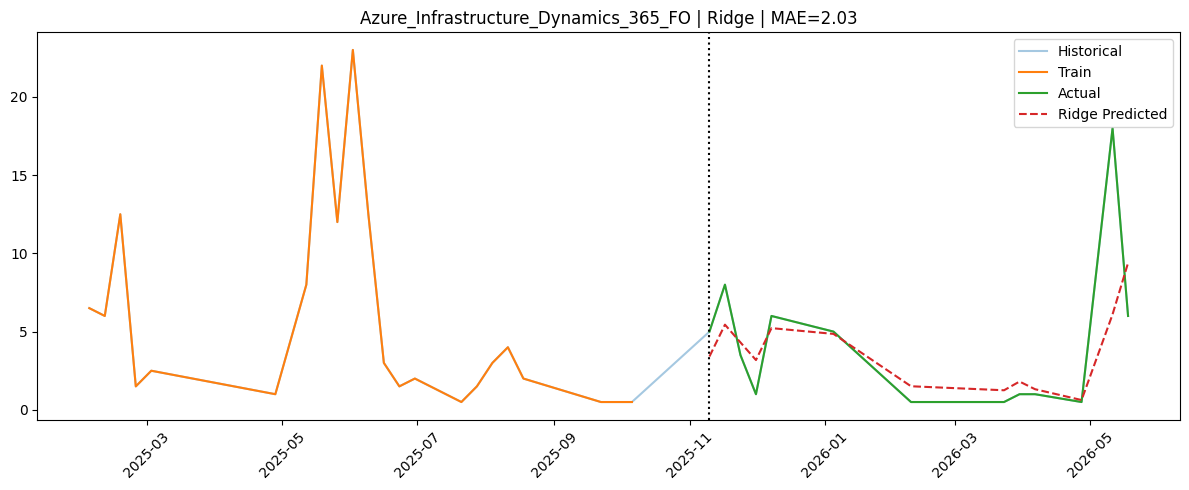

Azure_Infrastructure_Dynamics_365_FO | SHAP saved
Saved: saved_models\Azure_Infrastructure__Dynamics_365_FO__Ridge.pkl
Skipping Azure_Infrastructure_Dynamics_NAV - insufficient observations
Skipping Azure_Infrastructure_Microsoft_Azure - insufficient observations
Skipping Azure_Infrastructure_Microsoft_Cloud_Data_Warehouse - insufficient observations
Skipping Azure_Infrastructure_Microsoft_Cloud_Support_Infrastructure - insufficient observations
Skipping Azure_Integration_Dynamics_365_BC - insufficient observations

Azure_Integration_Dynamics_365_CE | BEST: BayesianRidge | MAPE: 0.455 | MAE: 3.810


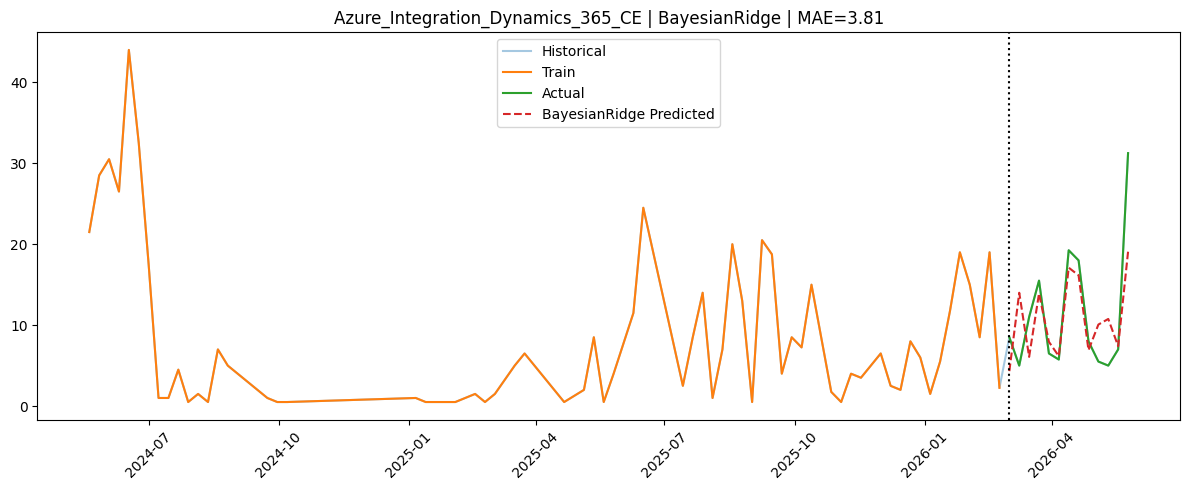

Azure_Integration_Dynamics_365_CE | SHAP saved
Saved: saved_models\Azure_Integration__Dynamics_365_CE__BayesianRidge.pkl

Azure_Integration_Dynamics_365_FO | BEST: Ridge | MAPE: 0.197 | MAE: 6.086


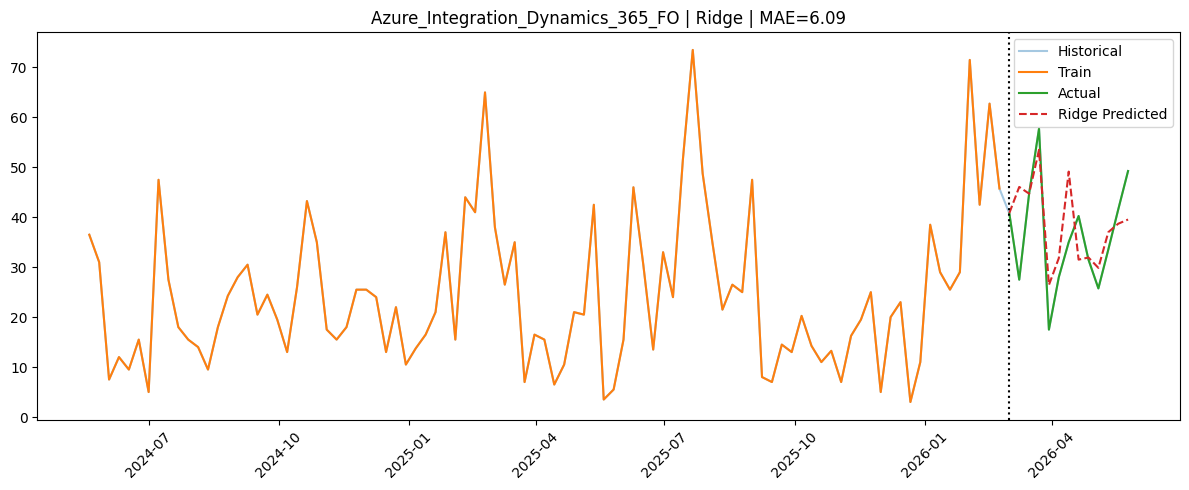

Azure_Integration_Dynamics_365_FO | SHAP saved
Saved: saved_models\Azure_Integration__Dynamics_365_FO__Ridge.pkl

Azure_Integration_Dynamics_365_FSCM | BEST: RandomForest | MAPE: 1.421 | MAE: 1.754


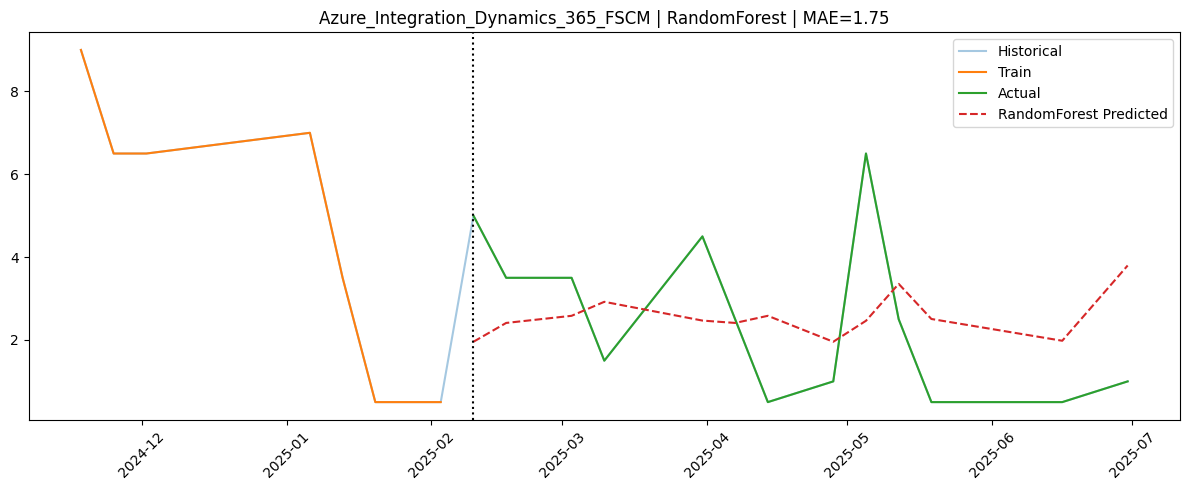

Azure_Integration_Dynamics_365_FSCM | SHAP saved
Saved: saved_models\Azure_Integration__Dynamics_365_FSCM__RandomForest.pkl

Azure_Integration_Dynamics_NAV | BEST: BayesianRidge | MAPE: 1.468 | MAE: 3.500


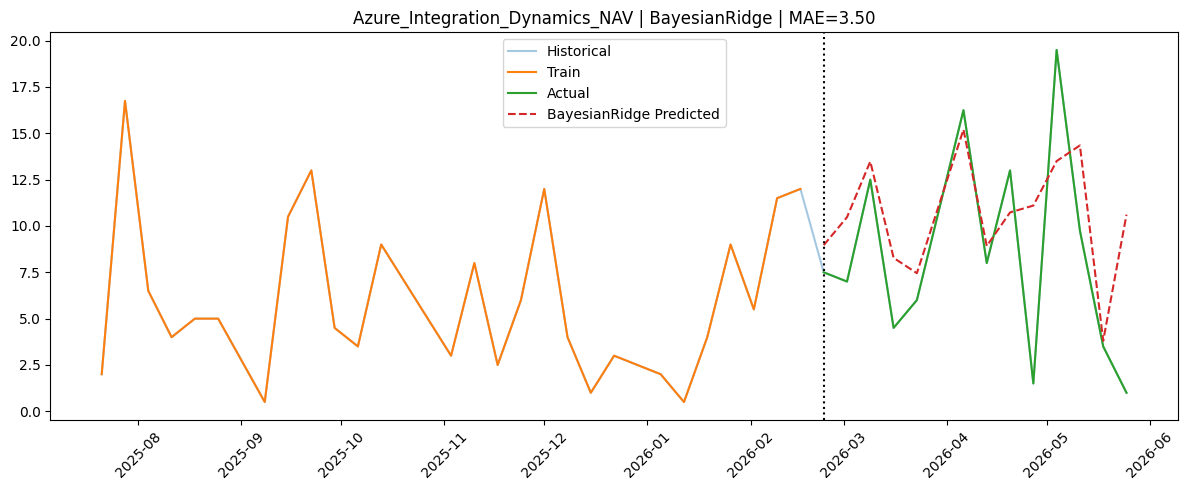

Azure_Integration_Dynamics_NAV | SHAP saved
Saved: saved_models\Azure_Integration__Dynamics_NAV__BayesianRidge.pkl

Azure_Integration_Microsoft_Azure | BEST: Ridge | MAPE: 0.220 | MAE: 4.929


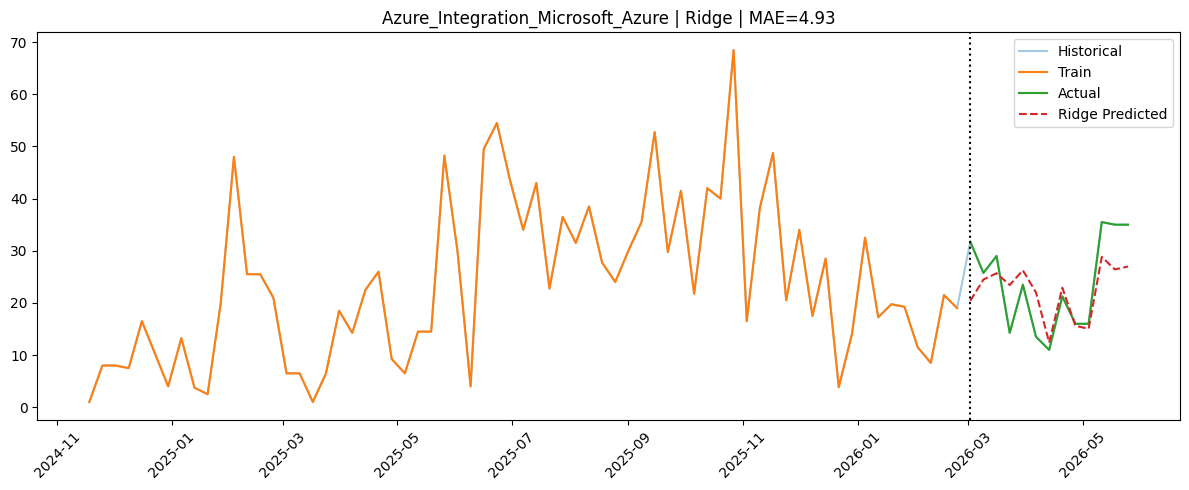

Azure_Integration_Microsoft_Azure | SHAP saved
Saved: saved_models\Azure_Integration__Microsoft_Azure__Ridge.pkl
Skipping Azure_Integration_Microsoft_Cloud_Data_Warehouse - insufficient observations
Skipping Azure_Integration_Power_Platform - insufficient observations

BC_Technical_Dynamics_365_BC | BEST: GradientBoosting | MAPE: 0.419 | MAE: 3.261


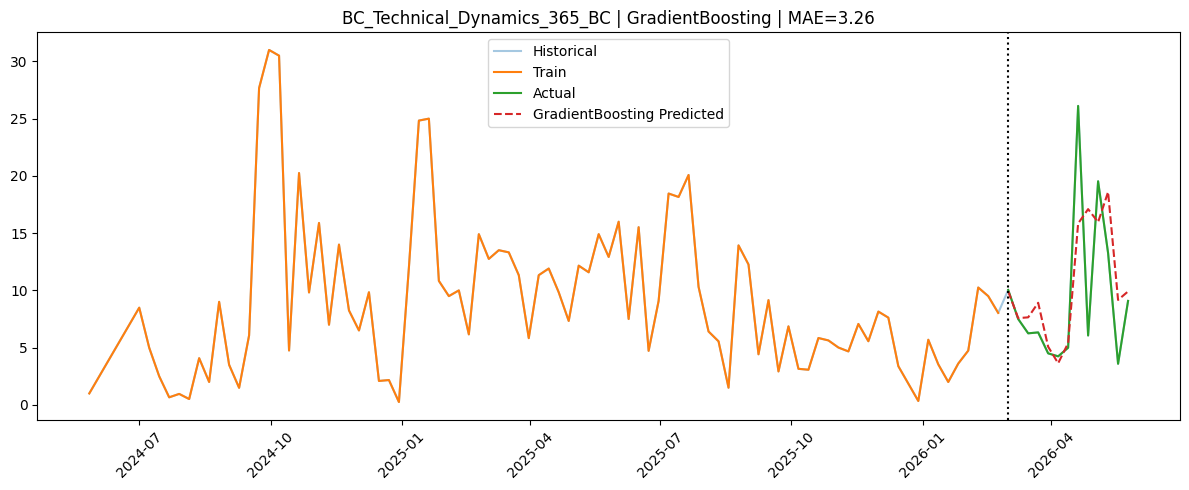

BC_Technical_Dynamics_365_BC | SHAP saved
Saved: saved_models\BC_Technical__Dynamics_365_BC__GradientBoosting.pkl

BC_Technical_Dynamics_NAV | BEST: Ridge | MAPE: 0.301 | MAE: 5.537


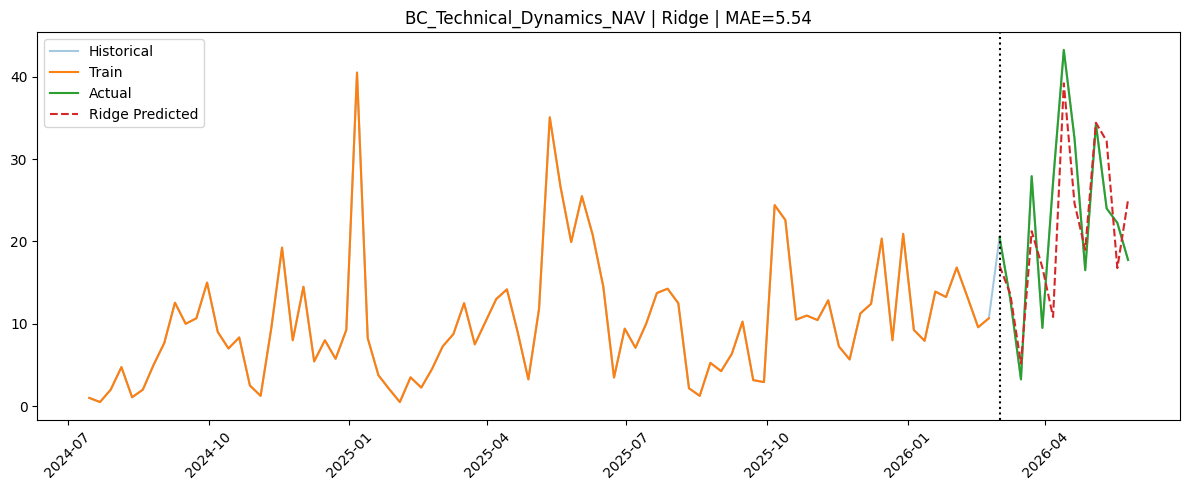

BC_Technical_Dynamics_NAV | SHAP saved
Saved: saved_models\BC_Technical__Dynamics_NAV__Ridge.pkl

CE_Functional_Dynamics_365_CE | BEST: Lasso | MAPE: 0.260 | MAE: 7.002


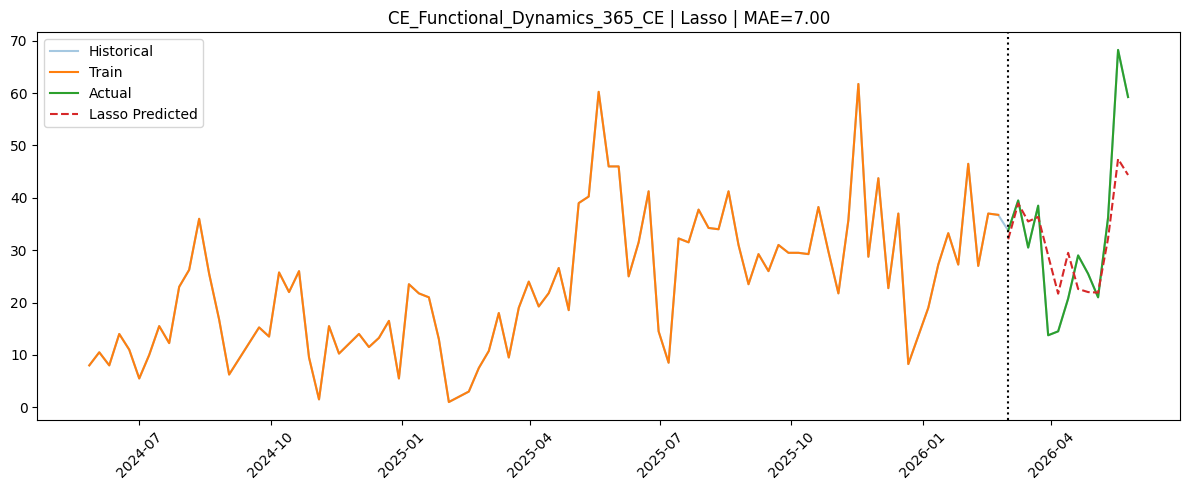

CE_Functional_Dynamics_365_CE | SHAP saved
Saved: saved_models\CE_Functional__Dynamics_365_CE__Lasso.pkl

CE_Functional_Dynamics_365_FO | BEST: Ridge | MAPE: 1.159 | MAE: 5.041


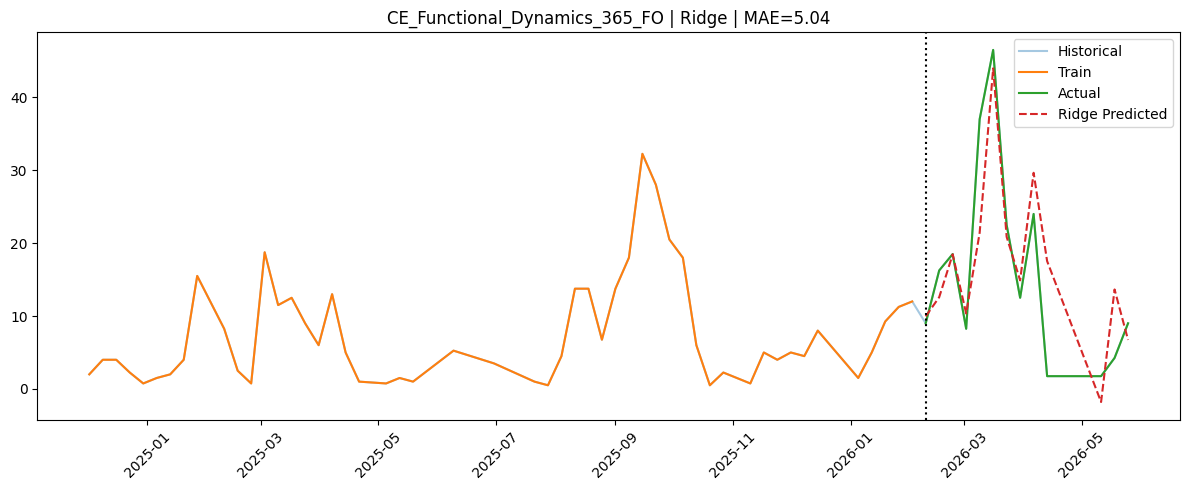

CE_Functional_Dynamics_365_FO | SHAP saved
Saved: saved_models\CE_Functional__Dynamics_365_FO__Ridge.pkl
Skipping CE_Functional_Dynamics_365_FSCM - insufficient observations
Skipping CE_Functional_Microsoft_Azure - insufficient observations
Skipping CE_Functional_Microsoft_Cloud_Data_Warehouse - insufficient observations

CE_Functional_Power_Platform | BEST: ExtraTrees | MAPE: 0.345 | MAE: 2.370


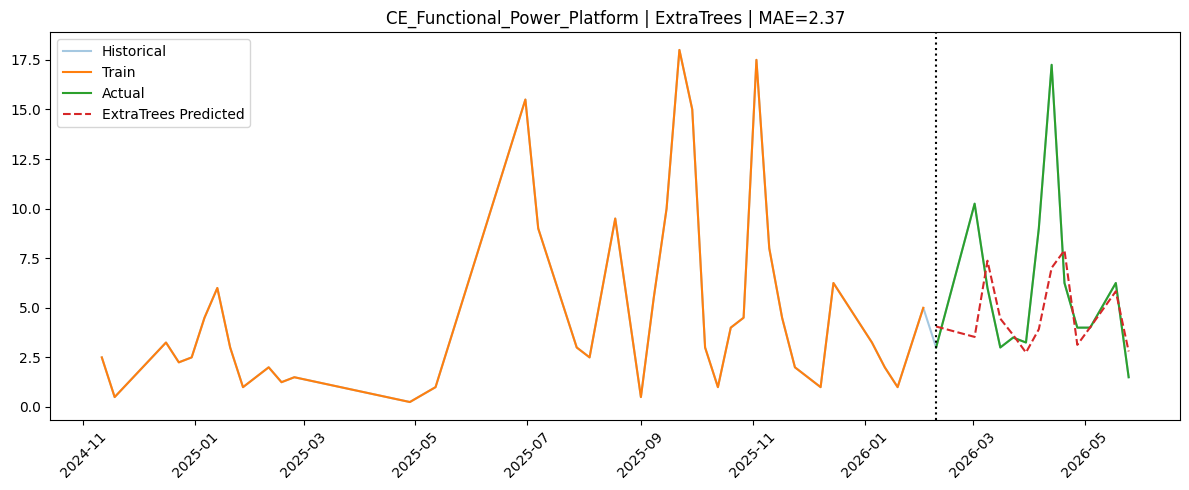

CE_Functional_Power_Platform | SHAP saved
Saved: saved_models\CE_Functional__Power_Platform__ExtraTrees.pkl

CE_Technical_Dynamics_365_CE | BEST: Huber | MAPE: 0.171 | MAE: 17.199


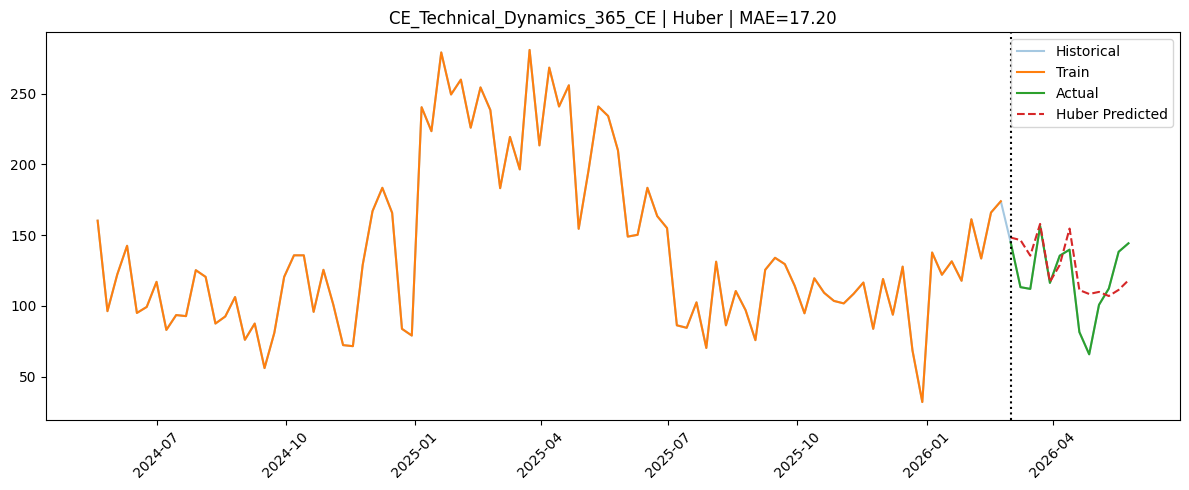

CE_Technical_Dynamics_365_CE | SHAP saved
Saved: saved_models\CE_Technical__Dynamics_365_CE__Huber.pkl

CE_Technical_Dynamics_365_FO | BEST: Lasso | MAPE: 0.198 | MAE: 5.125


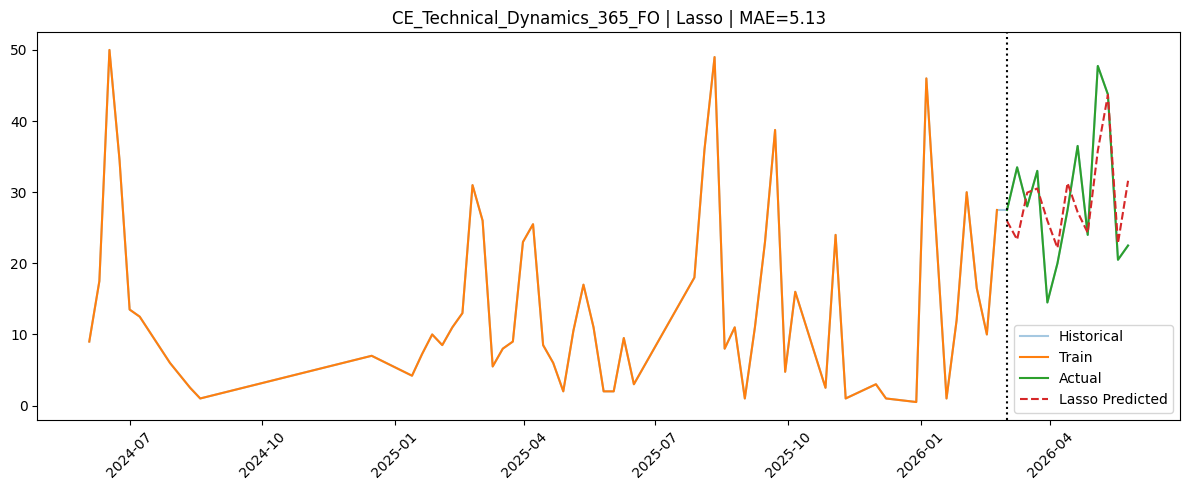

CE_Technical_Dynamics_365_FO | SHAP saved
Saved: saved_models\CE_Technical__Dynamics_365_FO__Lasso.pkl
Skipping CE_Technical_Dynamics_365_FSCM - insufficient observations

CE_Technical_Microsoft_Azure | BEST: BayesianRidge | MAPE: 1.082 | MAE: 1.899


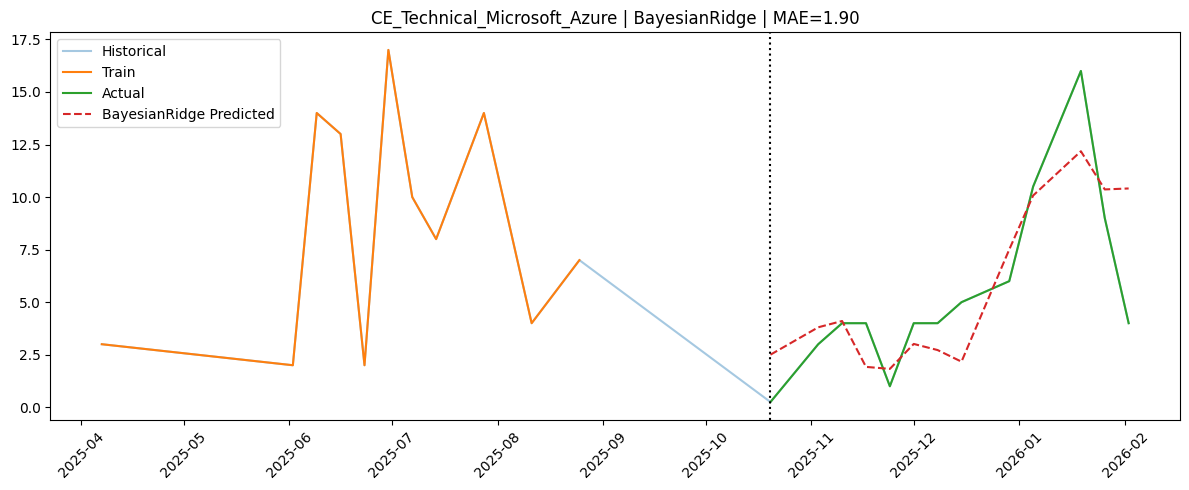

CE_Technical_Microsoft_Azure | SHAP saved
Saved: saved_models\CE_Technical__Microsoft_Azure__BayesianRidge.pkl

CE_Technical_Microsoft_Cloud_Data_Warehouse | BEST: Lasso | MAPE: 1.384 | MAE: 1.896


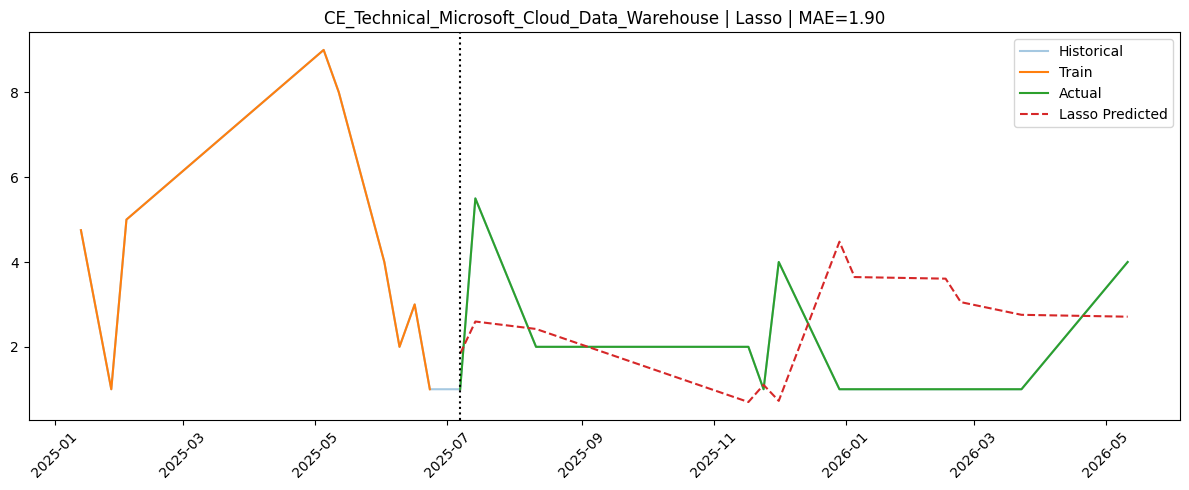

CE_Technical_Microsoft_Cloud_Data_Warehouse | SHAP saved
Saved: saved_models\CE_Technical__Microsoft_Cloud_Data_Warehouse__Lasso.pkl

CE_Technical_Power_Platform | BEST: Huber | MAPE: 0.722 | MAE: 3.729


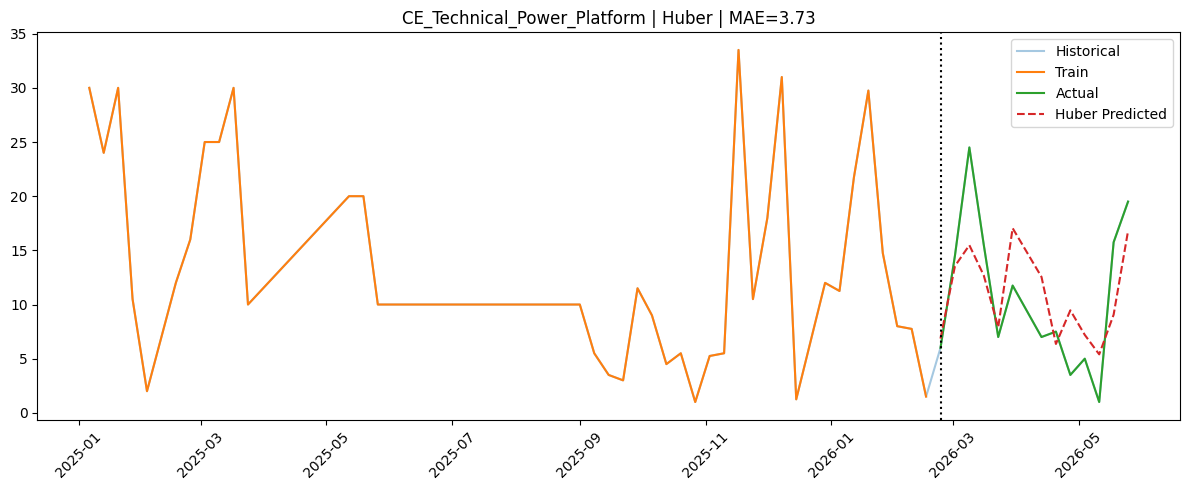

CE_Technical_Power_Platform | SHAP saved
Saved: saved_models\CE_Technical__Power_Platform__Huber.pkl

Data_Dynamics_365_BC | BEST: GradientBoosting | MAPE: 0.675 | MAE: 5.238


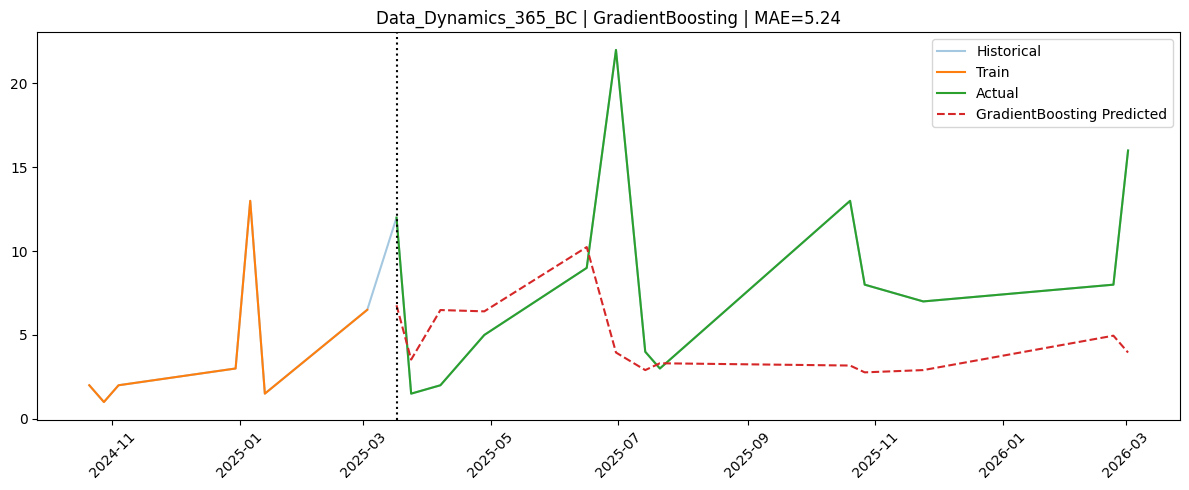

Data_Dynamics_365_BC | SHAP saved
Saved: saved_models\Data_Dynamics__365_BC__GradientBoosting.pkl

Data_Dynamics_365_CE | BEST: BayesianRidge | MAPE: 0.749 | MAE: 9.982


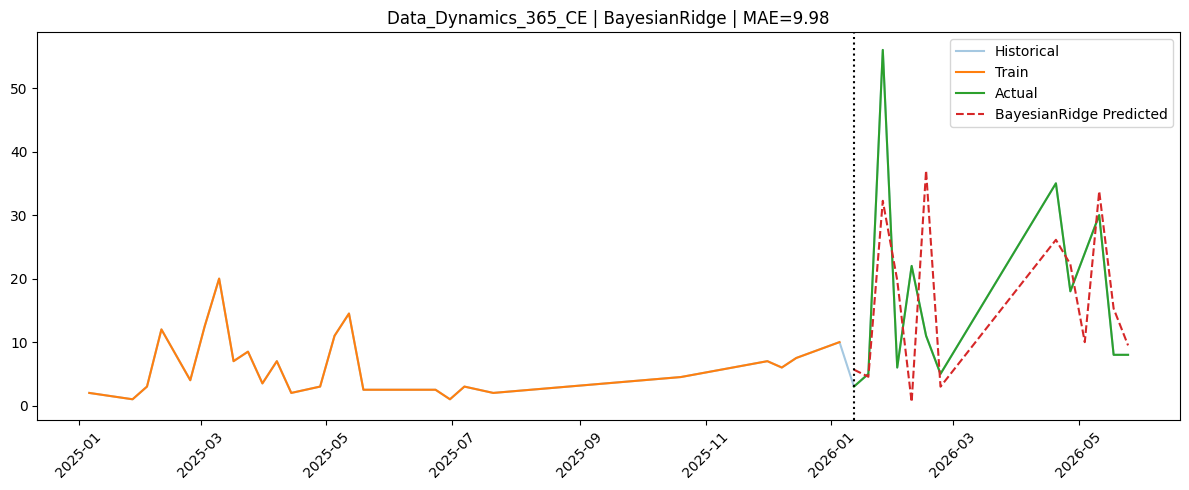

Data_Dynamics_365_CE | SHAP saved
Saved: saved_models\Data_Dynamics__365_CE__BayesianRidge.pkl

Data_Dynamics_365_FO | BEST: Huber | MAPE: 3.681 | MAE: 10.108


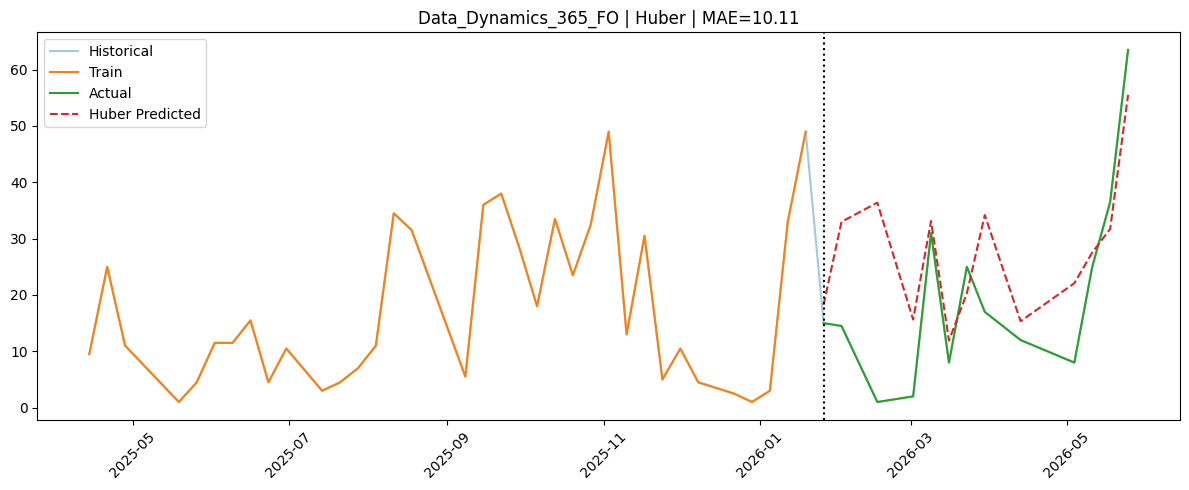

Data_Dynamics_365_FO | SHAP saved
Saved: saved_models\Data_Dynamics__365_FO__Huber.pkl
Skipping Data_Microsoft_Azure - insufficient observations

Data_Microsoft_Cloud_Data_Warehouse | BEST: BayesianRidge | MAPE: 0.610 | MAE: 10.859


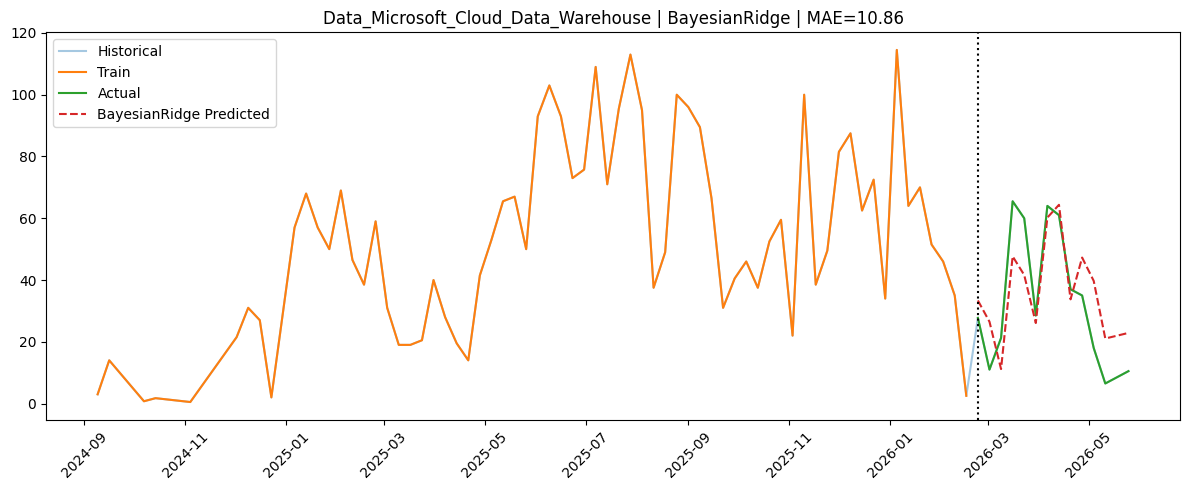

Data_Microsoft_Cloud_Data_Warehouse | SHAP saved
Saved: saved_models\Data_Microsoft__Cloud_Data_Warehouse__BayesianRidge.pkl

FO_Functional_Dynamics_365_CE | BEST: XGBoost | MAPE: 0.575 | MAE: 0.929


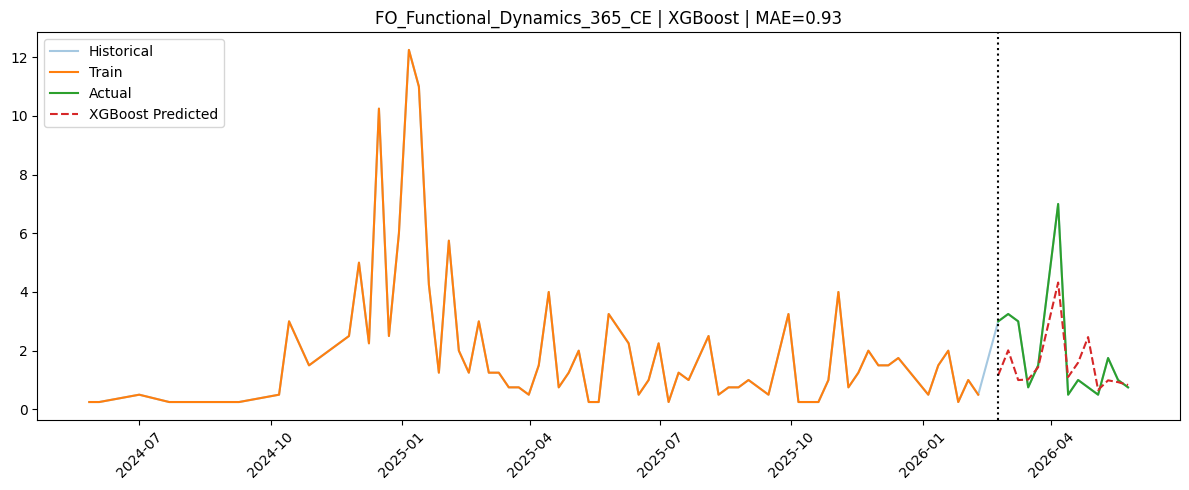

FO_Functional_Dynamics_365_CE | SHAP saved
Saved: saved_models\FO_Functional__Dynamics_365_CE__XGBoost.pkl

FO_Functional_Dynamics_365_FO | BEST: BayesianRidge | MAPE: 0.133 | MAE: 27.775


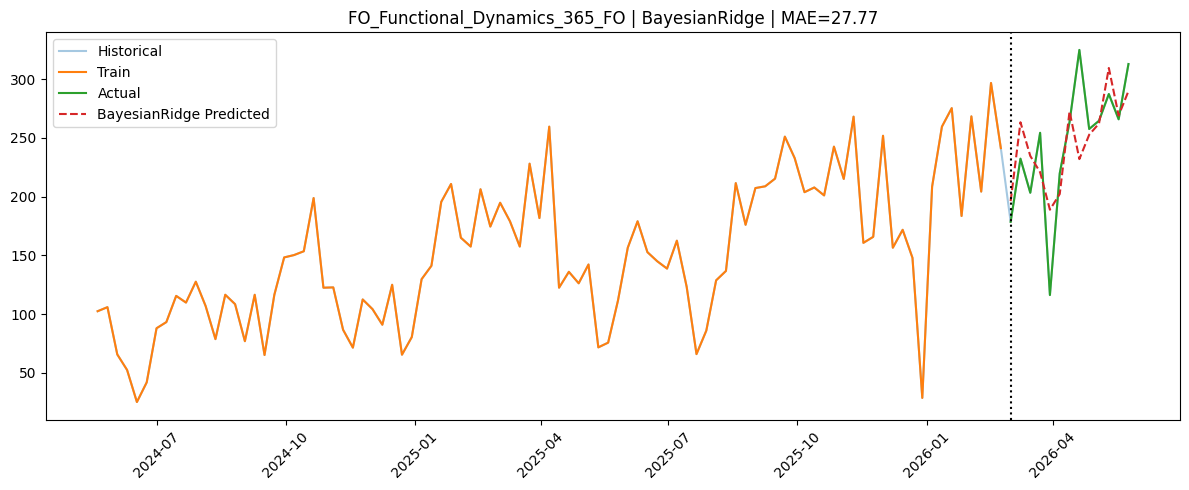

FO_Functional_Dynamics_365_FO | SHAP saved
Saved: saved_models\FO_Functional__Dynamics_365_FO__BayesianRidge.pkl

FO_Functional_Dynamics_365_FSCM | BEST: Ridge | MAPE: 6.190 | MAE: 5.080


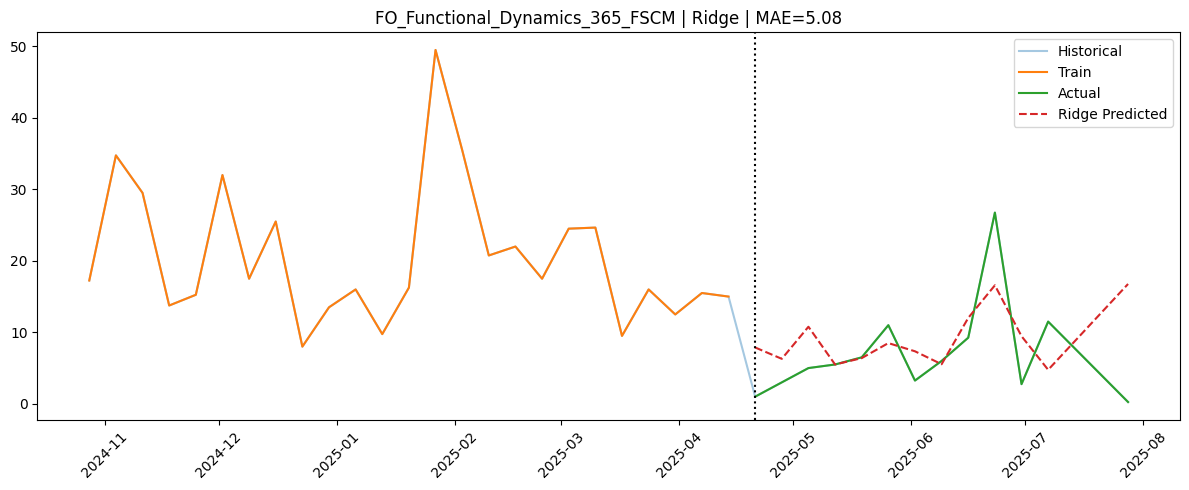

FO_Functional_Dynamics_365_FSCM | SHAP saved
Saved: saved_models\FO_Functional__Dynamics_365_FSCM__Ridge.pkl

FO_Functional_Microsoft_Azure | BEST: Lasso | MAPE: 0.500 | MAE: 2.354


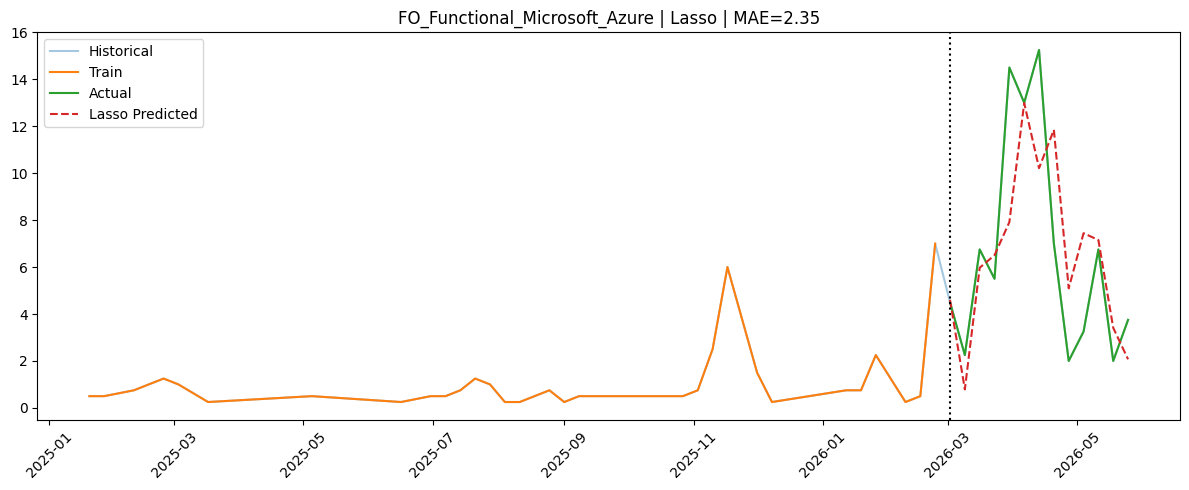

FO_Functional_Microsoft_Azure | SHAP saved
Saved: saved_models\FO_Functional__Microsoft_Azure__Lasso.pkl

FO_Functional_Microsoft_Cloud_Data_Warehouse | BEST: XGBoost | MAPE: 0.703 | MAE: 0.264


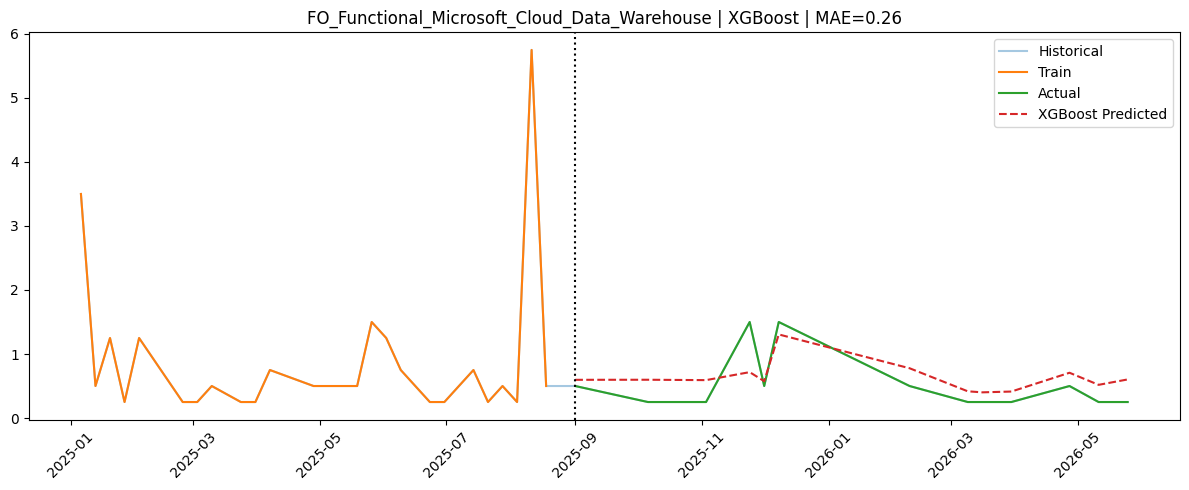

FO_Functional_Microsoft_Cloud_Data_Warehouse | SHAP saved
Saved: saved_models\FO_Functional__Microsoft_Cloud_Data_Warehouse__XGBoost.pkl
Skipping FO_Functional_Power_Platform - insufficient observations

FO_Technical_Dynamics_365_CE | BEST: Ridge | MAPE: 1.416 | MAE: 3.168


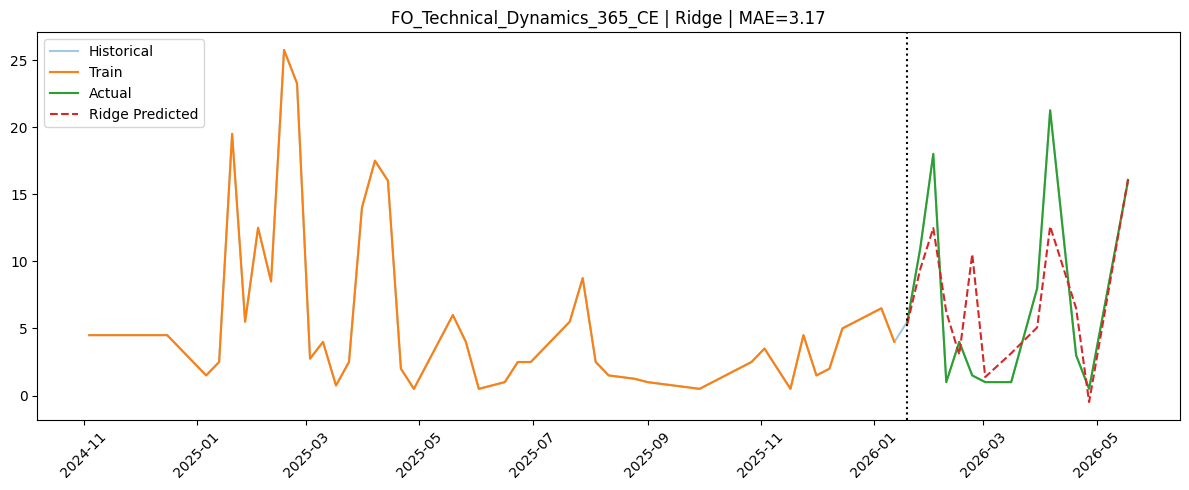

FO_Technical_Dynamics_365_CE | SHAP saved
Saved: saved_models\FO_Technical__Dynamics_365_CE__Ridge.pkl

FO_Technical_Dynamics_365_FO | BEST: Huber | MAPE: 0.104 | MAE: 18.538


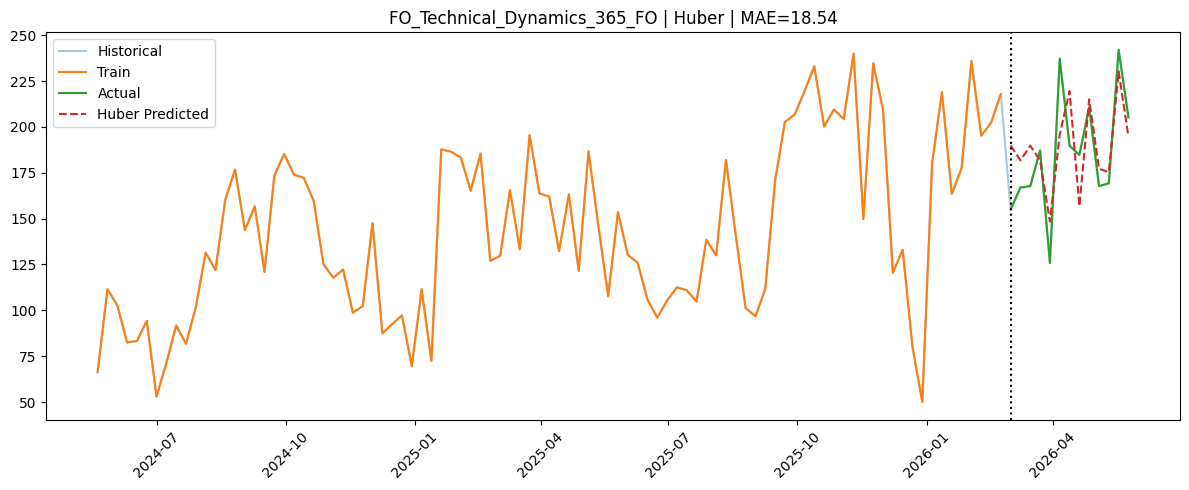

FO_Technical_Dynamics_365_FO | SHAP saved
Saved: saved_models\FO_Technical__Dynamics_365_FO__Huber.pkl

FO_Technical_Dynamics_365_FSCM | BEST: ElasticNet | MAPE: 1.225 | MAE: 2.932


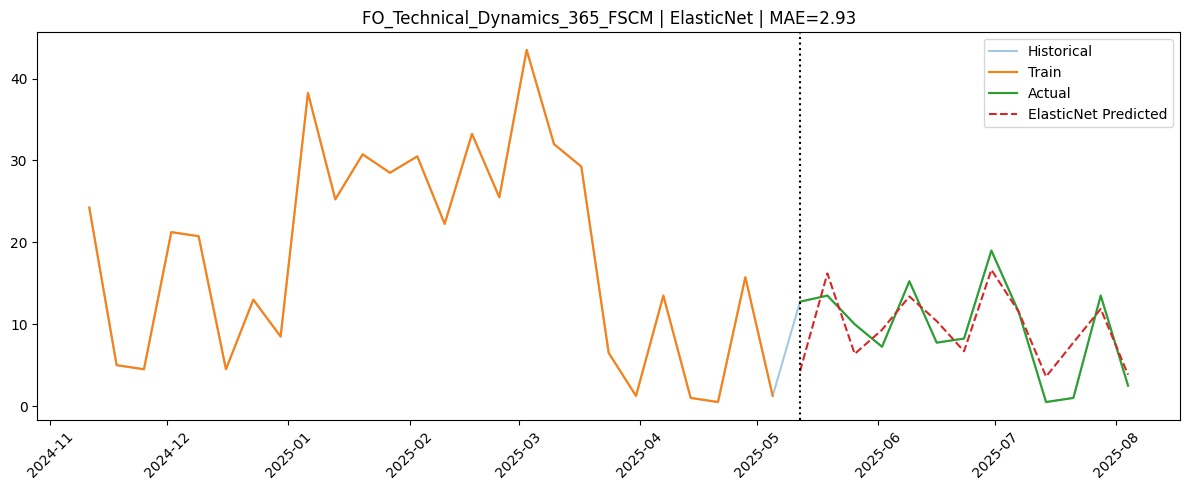

FO_Technical_Dynamics_365_FSCM | SHAP saved
Saved: saved_models\FO_Technical__Dynamics_365_FSCM__ElasticNet.pkl

FO_Technical_Microsoft_Azure | BEST: Huber | MAPE: 0.667 | MAE: 2.092


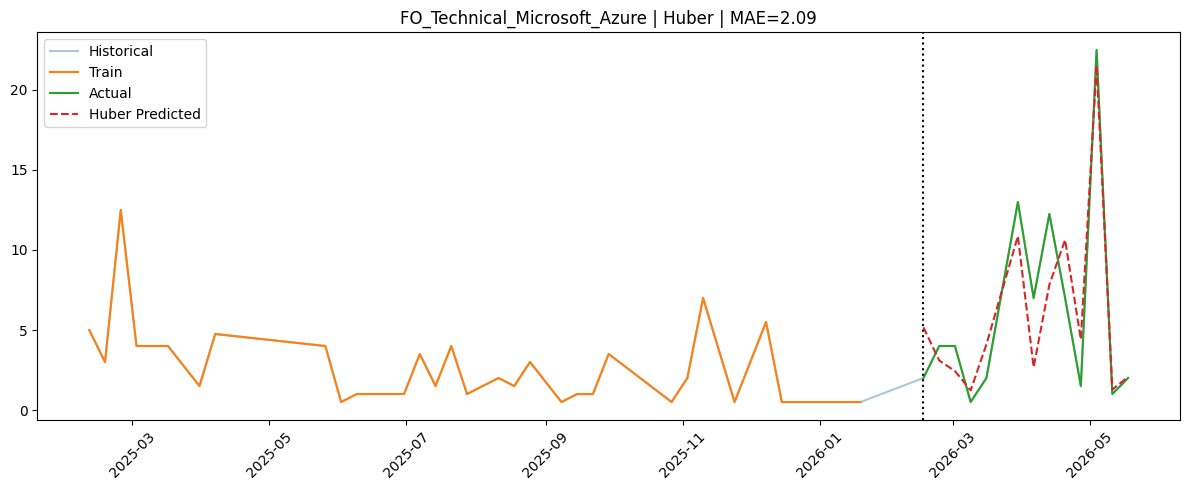

FO_Technical_Microsoft_Azure | SHAP saved
Saved: saved_models\FO_Technical__Microsoft_Azure__Huber.pkl
Skipping FO_Technical_Microsoft_Cloud_Data_Warehouse - insufficient observations
Skipping FO_Technical_Power_Platform - insufficient observations
Skipping SDM_Dynamics_365_BC - insufficient observations
Skipping SDM_Dynamics_365_CE - insufficient observations

SDM_Dynamics_365_FO | BEST: Lasso | MAPE: 0.466 | MAE: 3.095


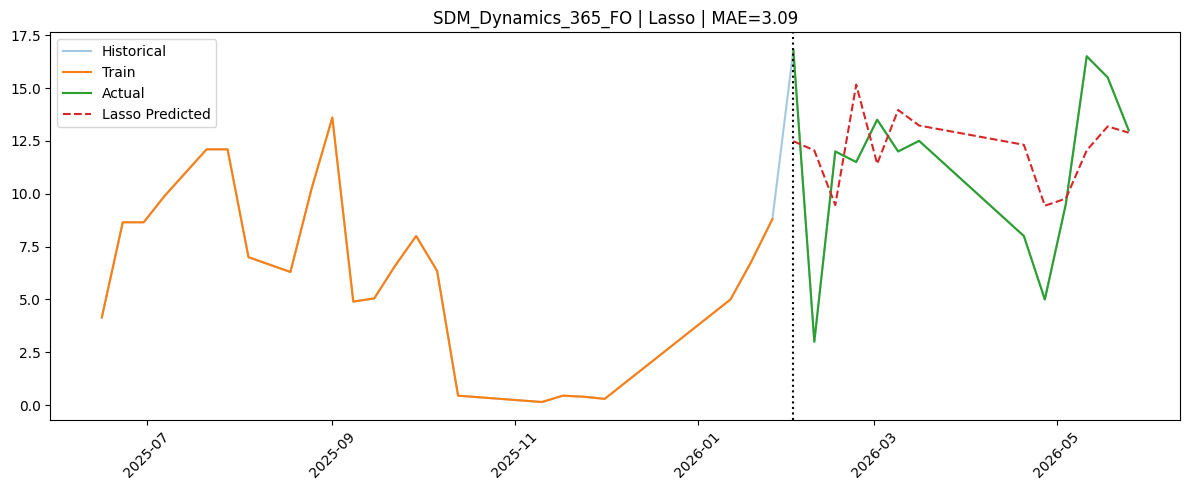

SDM_Dynamics_365_FO | SHAP saved
Saved: saved_models\SDM_Dynamics__365_FO__Lasso.pkl
Skipping SDM_Dynamics_NAV - insufficient observations
Skipping SDM_Microsoft_Cloud_Data_Warehouse - insufficient observations
Skipping SDM_Microsoft_Cloud_Support_Infrastructure - insufficient observations
Skipping SDM_Power_Platform - insufficient observations


,model,MAE,MAPE,n_obs,best_params
group,,,,,
Azure_Infrastructure_Dynamics_365_FO,Ridge,2.027987,0.718079,34,{'alpha': 10}
Azure_Integration_Dynamics_365_CE,BayesianRidge,3.810347,0.455064,79,"{'lambda_1': 1e-05, 'alpha_1': 1e-06}"
Azure_Integration_Dynamics_365_FO,Ridge,6.086148,0.197087,106,{'alpha': 10}
Azure_Integration_Dynamics_365_FSCM,RandomForest,1.754346,1.421048,20,"{'n_estimators': 500, 'max_depth': 3}"
Azure_Integration_Dynamics_NAV,BayesianRidge,3.500185,1.468047,41,"{'lambda_1': 1e-06, 'alpha_1': 1e-05}"
Azure_Integration_Microsoft_Azure,Ridge,4.928668,0.220363,79,{'alpha': 0.1}
BC_Technical_Dynamics_365_BC,GradientBoosting,3.260774,0.419364,100,"{'n_estimators': 100, 'learning_rate': 0.05}"
BC_Technical_Dynamics_NAV,Ridge,5.537404,0.300755,97,{'alpha': 1}
CE_Functional_Dynamics_365_CE,Lasso,7.002500,0.259695,101,{'alpha': 1}


,group,feature,importance
0,Azure_Infrastructure_Dynamics_365_FO,rolling_4,4.223357e-01
1,Azure_Infrastructure_Dynamics_365_FO,lag_1,4.012941e-01
2,Azure_Infrastructure_Dynamics_365_FO,week_of_year,1.704259e-01
3,Azure_Infrastructure_Dynamics_365_FO,lag_2,3.789759e-03
4,Azure_Infrastructure_Dynamics_365_FO,is_month_end,2.154592e-03
5,Azure_Infrastructure_Dynamics_365_FO,is_spike,0.000000e+00
6,Azure_Infrastructure_Dynamics_365_FO,is_dip,0.000000e+00
7,Azure_Infrastructure_Dynamics_365_FO,is_holiday,0.000000e+00
8,Azure_Infrastructure_Dynamics_365_FO,is_sick_or_holiday,0.000000e+00
9,Azure_Infrastructure_Dynamics_365_FO,is_quarter_end,0.000000e+00


In [69]:
results_list = []
feature_importance_results = []

model_dir = Path("saved_models")
model_dir.mkdir(exist_ok=True)

shap_dir = Path("shap_outputs")
shap_dir.mkdir(exist_ok=True)


for i in grouped_dfs:

    df_group = grouped_dfs[i].copy()

    if "week" in df_group.columns:
        df_group = df_group.sort_values("week")

    df_group["lag_1"] = df_group["Time worked"].shift(1)
    df_group["lag_2"] = df_group["Time worked"].shift(2)
    df_group["rolling_4"] = df_group["Time worked"].rolling(4).mean()

    df_group = df_group.dropna()

    if len(df_group) < 20:
        print(f"Skipping {i} - insufficient observations")
        continue

    y = df_group["Time worked"]

    X = df_group.drop(
        columns=["Time worked", "week"],
        errors="ignore"
    )

    test_size = 13

    split_idx = len(df_group) - test_size

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    tscv = TimeSeriesSplit(n_splits=5)

    models = {

        # Linear
        "Ridge": (
            Ridge(),
            {"alpha": [0.01, 0.1, 1, 10]}
        ),

        "Lasso": (
            Lasso(),
            {"alpha": [0.01, 0.1, 1]}
        ),

        "ElasticNet": (
            ElasticNet(),
            {"alpha": [0.01, 0.1, 1]}
        ),

        "BayesianRidge": (
            BayesianRidge(),
            {
                "alpha_1": [1e-6, 1e-5],
                "lambda_1": [1e-6, 1e-5]
            }
        ),

        "Huber": (
            HuberRegressor(),
            {
                "epsilon": [1.1, 1.35, 1.5]
            }
        ),

        # Tree-based
        "DecisionTree": (
            DecisionTreeRegressor(),
            {
                "max_depth": [3, 5, 10]
            }
        ),

        "RandomForest": (
            RandomForestRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500],
                "max_depth": [3, 5, 10]
            }
        ),

        "ExtraTrees": (
            ExtraTreesRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500]
            }
        ),

        "GradientBoosting": (
            GradientBoostingRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500],
                "learning_rate": [0.05, 0.1]
            }
        ),

        "AdaBoost": (
            AdaBoostRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500]
            }
        ),

        # Boosting
        "XGBoost": (
            XGBRegressor(
                random_state=42
            ),
            {
                "n_estimators": [100, 200, 500],
                "max_depth": [3, 5],
                "learning_rate": [0.05, 0.1]
            }
        ),

        "LightGBM": (
            LGBMRegressor(
                verbosity=-1,
                random_state=42
            ),
            {
                "n_estimators": [100, 200, 500],
                "num_leaves": [15, 31],
                "learning_rate": [0.05, 0.1]
            }
        ),

        # Other
        "SVR": (
            SVR(),
            {
                "C": [0.1, 1, 10]
            }
        ),

        "KNN": (
            KNeighborsRegressor(),
            {
                "n_neighbors": [3, 5, 7]
            }
        )
    }

    best_model = None
    best_preds = None
    best_mae = float("inf")
    best_mape = float("inf")
    best_name = None

    # ==================================================
    # MODEL SEARCH
    # ==================================================

    for name, (model, param_grid) in models.items():

        try:

            search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grid,
                n_iter=20,
                cv=tscv,
                scoring="neg_mean_absolute_error",
                random_state=42,
                n_jobs=-1
            )

            search.fit(X_train, y_train)

            best_estimator = search.best_estimator_

            preds = best_estimator.predict(X_test)

            mae = mean_absolute_error(
                y_test,
                preds
            )

            mape = mean_absolute_percentage_error(
                y_test,
                preds
            )

            results_list.append({
                "group": i,
                "model": name,
                "MAE": mae,
                "MAPE": mape,
                "n_obs": len(df_group),
                "best_params": search.best_params_
            })

            if mae < best_mae:

                best_mae = mae
                best_mape = mape

                best_model = best_estimator
                best_preds = preds
                best_name = name

        except Exception as e:

            print(
                f"{i} | {name} failed: {e}"
            )

    print(
        f"\n{i} | BEST: {best_name} | "
        f"MAPE: {best_mape:.3f} | "
        f"MAE: {best_mae:.3f}"
    )

    # ==================================================
    # PLOT TEST RESULTS
    # ==================================================

    plt.figure(figsize=(12, 5))

    weeks = df_group["week"]

    plt.plot(
        weeks,
        y,
        label="Historical",
        alpha=0.4
    )

    plt.plot(
        weeks[:split_idx],
        y_train,
        label="Train"
    )

    plt.plot(
        weeks[split_idx:],
        y_test,
        label="Actual"
    )

    plt.plot(
        weeks[split_idx:],
        best_preds,
        linestyle="--",
        label=f"{best_name} Predicted"
    )

    plt.axvline(
        weeks.iloc[split_idx],
        color="black",
        linestyle=":"
    )

    plt.xticks(rotation=45)

    plt.title(
        f"{i} | {best_name} | MAE={best_mae:.2f}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==================================================
    # XGBOOST EXPLAINABILITY
    # ==================================================

    try:

        explain_model = XGBRegressor(
            random_state=42,
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1
        )

        explain_model.fit(
            X_train,
            y_train
        )

        importance_df = pd.DataFrame({
            "group": i,
            "feature": X.columns,
            "importance": explain_model.feature_importances_
        })

        importance_df = importance_df.sort_values(
            "importance",
            ascending=False
        )

        feature_importance_results.append(
            importance_df
        )

        sample_size = min(
            1000,
            len(X_train)
        )

        shap_sample = X_train.sample(
            sample_size,
            random_state=42
        )

        explainer = shap.TreeExplainer(
            explain_model
        )

        shap_values = explainer.shap_values(
            shap_sample
        )

        safe_name = re.sub(
            r"[^A-Za-z0-9_-]",
            "_",
            str(i)
        )

        shap.summary_plot(
            shap_values,
            shap_sample,
            show=False
        )

        plt.tight_layout()

        plt.savefig(
            shap_dir /
            f"{safe_name}_shap_summary.png",
            bbox_inches="tight"
        )

        plt.close()

        shap.summary_plot(
            shap_values,
            shap_sample,
            plot_type="bar",
            show=False
        )

        plt.tight_layout()

        plt.savefig(
            shap_dir /
            f"{safe_name}_shap_bar.png",
            bbox_inches="tight"
        )

        plt.close()

        print(
            f"{i} | SHAP saved"
        )

    except Exception as e:

        print(
            f"{i} | SHAP failed: {e}"
        )

    # ==================================================
    # SAVE MODEL
    # ==================================================

    if best_model is not None:

        # retrain winner on ALL DATA
        best_model.fit(X, y)

        parts = str(i).split("_")

        specialisation = "_".join(parts[:2])

        technology = (
            "_".join(parts[2:])
            if len(parts) > 2
            else "unknown"
        )

        specialisation = re.sub(
            r"[^A-Za-z0-9_-]",
            "_",
            specialisation
        )

        technology = re.sub(
            r"[^A-Za-z0-9_-]",
            "_",
            technology
        )

        model_filename = (
            model_dir /
            f"{specialisation}__{technology}__{best_name}.pkl"
        )

        model_package = {

            "model": best_model,

            "features": list(X.columns),

            "history": (
                df_group["Time worked"]
                .tail(20)
                .tolist()
            ),

            "last_week": (
                df_group["week"]
                .max()
            ),

            "specialisation": specialisation,
            "technology": technology,

            "best_model_name": best_name,

            "mae": best_mae,
            "mape": best_mape
        }

        with open(
            model_filename,
            "wb"
        ) as f:

            pickle.dump(
                model_package,
                f
            )

        print(
            f"Saved: {model_filename}"
        )

# ==================================================
# RESULTS OUTPUT
# ==================================================

results_df = pd.DataFrame(results_list)

results_df = results_df.sort_values(
    ["group", "MAE"]
)

display(
    results_df.groupby("group").first()
)

results_df.to_csv(
    f"experiment_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv",
    index=False
)

# ==================================================
# FEATURE IMPORTANCES
# ==================================================

if feature_importance_results:

    feature_importances_df = pd.concat(
        feature_importance_results,
        ignore_index=True
    )

    feature_importances_df.to_csv(
        "xgboost_feature_importances.csv",
        index=False
    )

    top_features_df = (
        feature_importances_df
        .sort_values(
            ["group", "importance"],
            ascending=[True, False]
        )
        .groupby("group")
        .head(10)
    )

    top_features_df.to_csv(
        "xgboost_top_features.csv",
        index=False
    )

    display(top_features_df)

## Build Inference Pipeline

In [70]:
def forecast_future(
    model,
    features,
    history,
    future_inputs,
    horizon
):

    history = history.copy()

    predictions = []

    for step in range(horizon):

        row = {}

        # business features
        row["is_sick_holiday"] = future_inputs.iloc[step]["is_sick_holiday"]
        row["is_spike"] = future_inputs.iloc[step]["is_spike"]
        row["is_dip"] = future_inputs.iloc[step]["is_dip"]

        # autoregressive features
        row["lag_1"] = history[-1]
        row["lag_2"] = history[-2]
        row["rolling_4"] = np.mean(history[-4:])

        X_future = pd.DataFrame([row])

        # ensure feature order matches training
        X_future = X_future.reindex(
            columns=features,
            fill_value=0
        )

        pred = model.predict(X_future)[0]

        predictions.append(pred)

        # prediction becomes history
        history.append(pred)

    return predictions

In [ ]:
all_forecasts = []

for model_file in Path("saved_models").glob("*.pkl"):

    with open(model_file, "rb") as f:
        pkg = pickle.load(f)

    if "last_week" not in pkg:
        print(f"Skipping {model_file.name}: no last_week found")
        continue

    last_week = pd.to_datetime(pkg["last_week"])

    future_weeks = pd.date_range(
        start=last_week + pd.Timedelta(weeks=1),
        periods=13,
        freq="W"
    )

    future_inputs = pd.DataFrame({
        "week": future_weeks
    })

    # Calendar features
    future_inputs["week_of_year"] = (
        future_inputs["week"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    future_inputs["month"] = (
        future_inputs["week"]
        .dt.month
    )

    future_inputs["is_month_end"] = (
        future_inputs["week"]
        .dt.is_month_end
        .astype(int)
    )

    future_inputs["is_quarter_end"] = (
        future_inputs["week"]
        .dt.is_quarter_end
        .astype(int)
    )

    # Unknown future business inputs
    future_inputs["is_leave"] = 0
    future_inputs["is_sick_holiday"] = 0
    future_inputs["is_spike"] = 0
    future_inputs["is_dip"] = 0

    preds = forecast_future(
        model=pkg["model"],
        features=pkg["features"],
        history=pkg["history"],
        future_inputs=future_inputs,
        horizon=13
    )

    row = {
        "specialisation": pkg["specialisation"],
        "technology": pkg["technology"],
    }

    for idx, pred in enumerate(preds, start=1):
        row[f"week_{idx}"] = pred

    row["pxn_dt"] = pd.Timestamp.today().date()

    all_forecasts.append(row)

predictions_df = pd.DataFrame(all_forecasts)

predictions_df.to_csv(
    "predictions.csv",
    index=False
)

display(predictions_df)

,specialisation,technology,week_1,week_2,week_3,week_4,week_5,week_6,week_7,week_8,week_9,week_10,week_11,week_12,week_13,pxn_dt
0,Azure_Infrastructure,Dynamics_365_FO,-2.463387,4.453300,10.549337,2.929081,-1.306074,4.234792,6.277590,1.063332,-0.426840,3.269582,3.498785,0.149424,-0.030075,2026-07-02
1,Azure_Integration,Dynamics_365_CE,12.733489,1.834215,17.206598,27.199020,10.867526,5.986355,21.916733,24.341377,9.947702,10.973926,24.431017,21.738996,10.596583,2026-07-02
2,Azure_Integration,Dynamics_365_CE,24.900000,24.900000,24.900000,24.900000,24.900000,24.900000,24.900000,24.900000,24.900000,24.900000,24.900000,24.900000,24.900000,2026-07-02
3,Azure_Integration,Dynamics_365_FO,33.286524,37.085288,47.816991,44.954834,36.934408,43.107856,49.151861,43.885976,41.195702,47.486052,49.285242,44.736170,45.457945,2026-07-02
4,Azure_Integration,Dynamics_365_FSCM,3.343381,2.893910,2.177967,2.444635,2.464484,2.459482,2.455615,2.459482,2.459482,2.459482,2.459482,2.459482,2.459482,2026-07-02
5,Azure_Integration,Dynamics_NAV,10.083333,8.923077,4.888889,6.250000,10.600000,10.541667,6.500000,6.777778,9.428571,9.500000,9.266667,9.769231,11.833333,2026-07-02
6,Azure_Integration,Dynamics_NAV,14.536005,7.401889,3.361808,8.340419,11.281984,6.237411,6.618705,10.215601,9.289723,7.165435,8.951665,10.177760,8.802957,2026-07-02
7,Azure_Integration,Microsoft_Azure,26.588141,36.009044,36.637684,31.742497,32.042982,37.514453,35.507323,32.728323,35.713039,37.773208,35.203531,35.082798,37.827099,2026-07-02
8,BC_Technical,Dynamics_365_BC,12.895263,11.137297,9.795263,10.936429,10.936429,10.936429,10.936429,10.936429,10.936429,10.936429,10.936429,10.936429,10.936429,2026-07-02
9,BC_Technical,Dynamics_365_BC,21.393866,18.776500,17.299920,22.172367,18.304463,17.839990,17.962568,17.962568,17.962568,17.962568,17.962568,17.962568,17.962568,2026-07-02
